In [27]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,  confusion_matrix
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [4]:
df=sns.load_dataset("Iris")

In [5]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [7]:
df.drop(columns=["species"],inplace=True)

In [9]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [11]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
dtype: int64

In [14]:
from sklearn.cluster import KMeans
kmeans=KMeans(n_clusters=3,random_state=0, n_init='auto') 

In [15]:
kmeans.fit(df)


,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


In [16]:
labels=kmeans.predict(df)

In [17]:
centroids = kmeans.cluster_centers_

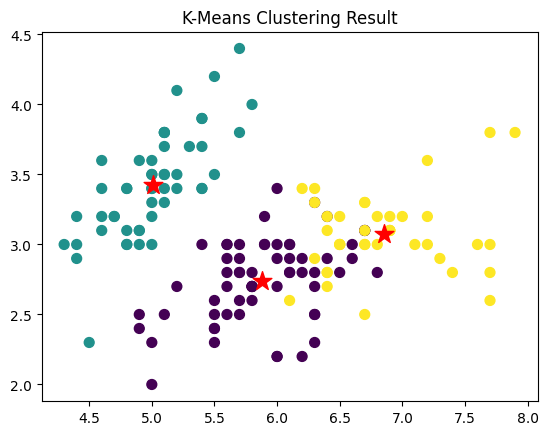

In [23]:
plt.scatter(df.iloc[:, 0], df.iloc[:, 1], c=labels, s=50, cmap='viridis')
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='*') # Plot centroids
plt.title("K-Means Clustering Result")
plt.show()

In [25]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df)

In [28]:
pca = PCA(n_components=2)
principal_components = pca.fit_transform(scaled_features)

In [29]:
pca_df = pd.DataFrame(data=principal_components, 
                      columns=['principal_component_1', 'principal_component_2'])

In [30]:
kmeans = KMeans(n_clusters=3, random_state=0, n_init='auto')

kmeans.fit(pca_df)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


In [31]:
labels = kmeans.predict(pca_df)
centroids = kmeans.cluster_centers_

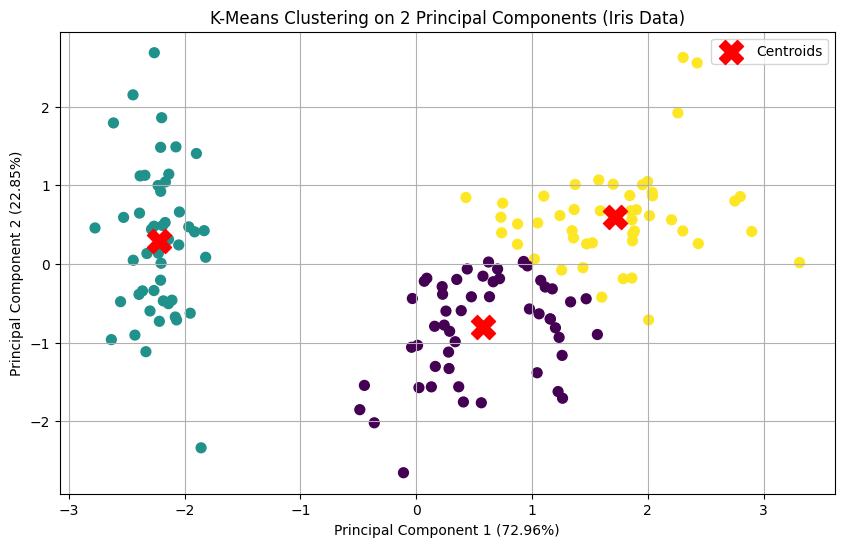

In [32]:
plt.figure(figsize=(10, 6))
plt.scatter(pca_df['principal_component_1'], pca_df['principal_component_2'], 
            c=labels, s=50, cmap='viridis')
plt.scatter(centroids[:, 0], centroids[:, 1], 
            c='red', s=300, marker='X', label='Centroids')

plt.title("K-Means Clustering on 2 Principal Components (Iris Data)")
plt.xlabel(f"Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}%)")
plt.ylabel(f"Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}%)")
plt.legend()
plt.grid(True)
plt.show()

In [33]:
from sklearn.metrics import silhouette_score